In [1]:
# Install the module when it is not available (e.g. on Colab). Locally: `pip install -e .` from the repository root.
try:
    import mvg
except ImportError:
    %pip install -q git+https://github.com/Rudip1/learn-computer-vision
    import mvg

# 1 · Projective geometry of the plane

**Recap** ([theory](../../1_theory/01_projective_geometry.md)).

* A point $(u, v)$ is the homogeneous vector $\mathbf{x} \simeq (u, v, 1)^\top$; vectors with $x_3 = 0$ are points at infinity.
* A line $au + bv + c = 0$ is $\mathbf{l} = (a, b, c)^\top$; incidence is $\mathbf{l}^\top \mathbf{x} = 0$.
* Line through two points: $\mathbf{x} \times \mathbf{y}$; intersection of two lines: $\mathbf{l} \times \mathbf{m}$.
* A homography maps points with $H$ and lines with $H^{-\top}$.
* Translation ⊂ Euclidean ⊂ similarity ⊂ affine ⊂ projective: each level keeps fewer invariants.
* $H = H_S H_A H_P$; knowing the vanishing line removes the projective part (affine rectification).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mvg
from mvg.plotting import setup, draw_line, draw_polygon, grid_lines

setup()
rng = np.random.default_rng(0)

## 1. Points and lines

The worked example of the theory file: the line through $(1,2)$ and $(3,4)$, and its intersection with $u = 2$.

l = [-2.  2. -2.]  -> normalized: [-0.70710678  0.70710678 -0.70710678]
intersection (homogeneous): [-4. -6. -2.]  -> (u, v) = [2. 3.]


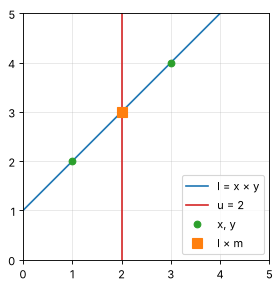

In [3]:
x, y = np.array([1, 2, 1.0]), np.array([3, 4, 1.0])
l = mvg.line_through(x, y)
m = np.array([1, 0, -2.0])          # u = 2
p = mvg.intersect_lines(l, m)
print("l =", l, " -> normalized:", mvg.normalize_line(l))
print("intersection (homogeneous):", p, " -> (u, v) =", p[:2] / p[2])

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(0, 5); ax.set_ylim(0, 5); ax.set_aspect("equal")
draw_line(ax, l, label="l = x × y")
draw_line(ax, m, label="u = 2")
ax.plot(*np.c_[x[:2], y[:2]], "o", label="x, y")
ax.plot(*(p[:2] / p[2]), "s", ms=9, label="l × m")
ax.legend(loc="lower right");

Parallel lines meet at a point with $x_3 = 0$, whose first two coordinates are the common direction (eq. 1.7).

In [4]:
l1, l2 = np.array([2.0, -3.0, 1.0]), np.array([2.0, -3.0, 5.0])
print("intersection of parallel lines:", mvg.intersect_lines(l1, l2))
print("lies on l_inf = (0,0,1):", np.isclose(mvg.intersect_lines(l1, l2) @ [0, 0, 1], 0))

intersection of parallel lines: [-12.  -8.   0.]
lies on l_inf = (0,0,1): True


### ✏️ Exercise 1.1 — distance from a point to a line

Implement eq. (1.8) without calling `mvg`. The test below compares your function with `mvg.point_line_distance`
on random points and lines.

In [5]:
def distance_point_line(pt, line):
    """Euclidean distance from pt = (u, v) to the line (a, b, c)."""
    a, b, c = line
    return abs(a * pt[0] + b * pt[1] + c) / np.hypot(a, b)

In [6]:
for _ in range(100):
    pt, line = rng.normal(size=2) * 10, rng.normal(size=3)
    assert np.isclose(distance_point_line(pt, line), mvg.point_line_distance(pt, line))
print("Exercise 1.1 passed")

Exercise 1.1 passed


## 2. The hierarchy of transformations

One transformation of each class applied to a unit grid with a circle drawn on it.

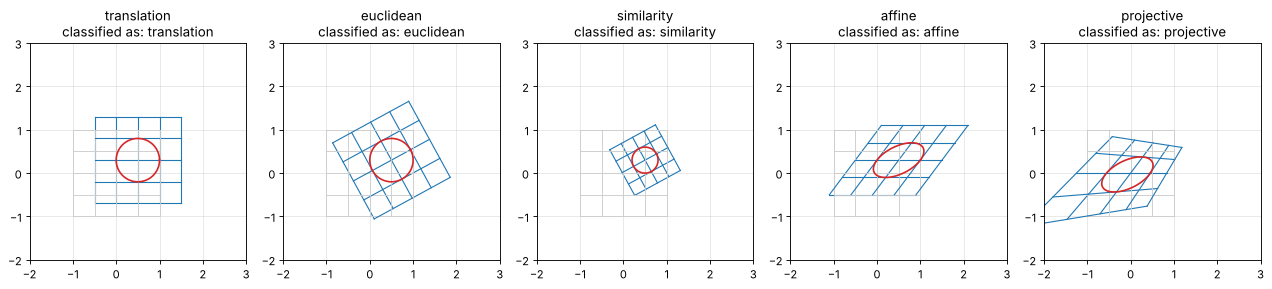

In [7]:
A = np.array([[1.0, 0.6], [0.0, 0.8]])
H_proj = mvg.make_affine(A, [0.0, 0.0]) @ np.array([[1, 0, 0], [0, 1, 0], [0.2, 0.15, 1.0]])
examples = {
    "translation": mvg.make_affine(np.eye(2), [0.5, 0.3]),
    "euclidean": mvg.make_euclidean(0.5, 0.5, 0.3),
    "similarity": mvg.make_similarity(0.6, 0.5, 0.5, 0.3),
    "affine": mvg.make_affine(A, [0.5, 0.3]),
    "projective": H_proj,
}
circle = 0.5 * np.c_[np.cos(np.linspace(0, 2 * np.pi, 100)), np.sin(np.linspace(0, 2 * np.pi, 100))]

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
for ax, (name, H) in zip(axes, examples.items()):
    for g in grid_lines(5):
        ax.plot(*g.T, color="0.8", lw=0.8)
        ax.plot(*mvg.apply_homography(H, g).T, color="C0", lw=1)
    ax.plot(*mvg.apply_homography(H, circle).T, color="C1")
    ax.set_title(f"{name}\nclassified as: {mvg.classify_transform(H).name.lower()}")
    ax.set_aspect("equal"); ax.set_xlim(-2, 3); ax.set_ylim(-2, 3)
plt.tight_layout()

Measure the invariants of the table in section 1.4 on a square, a pair of parallel sides and four collinear points.

In [8]:
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1.0]])
collinear = np.array([[0, 0], [0.25, 0.25], [0.75, 0.75], [1, 1.0]])


def invariants(H):
    s = mvg.apply_homography(H, square)
    side = np.linalg.norm(s[1] - s[0])
    d1, d2 = s[1] - s[0], s[3] - s[0]
    angle = np.degrees(np.arccos(d1 @ d2 / np.linalg.norm(d1) / np.linalg.norm(d2)))
    e1, e2 = s[1] - s[0], s[2] - s[3]  # opposite sides
    parallel = np.degrees(np.arcsin(abs(e1[0] * e2[1] - e1[1] * e2[0]) / np.linalg.norm(e1) / np.linalg.norm(e2)))
    cr = mvg.cross_ratio(mvg.apply_homography(H, collinear))
    return side, angle, parallel, cr


print(f"{'class':<12}{'side length':>12}{'corner angle':>14}{'opp. sides angle':>18}{'cross ratio':>13}")
for name, H in examples.items():
    print(f"{name:<12}" + "".join(f"{v:>{w}.4f}" for v, w in zip(invariants(H), (12, 14, 18, 13))))

class        side length  corner angle  opp. sides angle  cross ratio
translation       1.0000       90.0000            0.0000       1.1250
euclidean         1.0000       90.0000            0.0000       1.1250
similarity        0.6000       90.0000            0.0000       1.1250
affine            1.0000       53.1301            0.0000       1.1250
projective        0.8333       53.1301            8.8297       1.1250


Read the table column by column: lengths survive only translation and Euclidean maps, the right angle survives up
to similarity, parallelism (0°) up to affine, and only the cross ratio survives everything.

### ✏️ Exercise 1.2 — transforming a line

Write `transform_line(H, l)` with NumPy (eq. 1.10). The check maps two points and the line through them and
verifies that incidence is preserved.

In [9]:
def transform_line(H, l):
    return np.linalg.solve(H.T, l)

In [10]:
for _ in range(50):
    H = np.eye(3) + 0.3 * rng.normal(size=(3, 3))
    p, q = np.r_[rng.normal(size=2), 1], np.r_[rng.normal(size=2), 1]
    lp = transform_line(H, np.cross(p, q))
    lp /= np.linalg.norm(lp)
    assert abs(lp @ (H @ p)) < 1e-9 * np.linalg.norm(H @ p) and abs(lp @ (H @ q)) < 1e-9 * np.linalg.norm(H @ q)
    assert np.allclose(mvg.normalize_projective(lp), mvg.normalize_projective(mvg.transform_line(H, np.cross(p, q))))
print("Exercise 1.2 passed")

Exercise 1.2 passed


## 3. Which model explains the data?

Correspondences generated by a projective map plus 0.5 px of noise. Fitting each class of the hierarchy and
comparing the residuals shows which model is rich enough.

translation  rms transfer error =   46.894 px
euclidean    rms transfer error =   27.373 px
similarity   rms transfer error =   26.735 px
affine       rms transfer error =   20.301 px


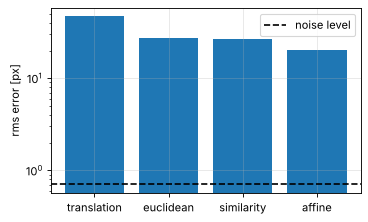

In [11]:
H_true = np.array([[1.05, 0.20, 12.0], [-0.10, 0.95, -6.0], [4e-4, -2e-4, 1.0]])
x = rng.uniform(-300, 300, size=(200, 2))
xp = mvg.apply_homography(H_true, x) + rng.normal(scale=0.5, size=x.shape)

classes = [mvg.TransformClass.TRANSLATION, mvg.TransformClass.EUCLIDEAN, mvg.TransformClass.SIMILARITY,
           mvg.TransformClass.AFFINE]
rms = {c.name.lower(): mvg.rms_transfer_error(mvg.fit_transform(c, x, xp), x, xp) for c in classes}
for name, r in rms.items():
    print(f"{name:<12} rms transfer error = {r:8.3f} px")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(list(rms), list(rms.values()))
ax.axhline(0.5 * np.sqrt(2), color="k", ls="--", label="noise level")
ax.set_yscale("log"); ax.set_ylabel("rms error [px]"); ax.legend();

None of the four classes reaches the noise level: the data needs the projective model of chapter 5.

### ✏️ Exercise 1.3 — least-squares similarity

Build the linear system (1.17) and solve it with `np.linalg.lstsq`. Return the $3 \times 3$ matrix.

In [12]:
def fit_similarity(x, xp):
    n = len(x)
    M = np.zeros((2 * n, 4))
    M[0::2] = np.c_[x[:, 0], -x[:, 1], np.ones(n), np.zeros(n)]
    M[1::2] = np.c_[x[:, 1], x[:, 0], np.zeros(n), np.ones(n)]
    a, b, tu, tv = np.linalg.lstsq(M, xp.reshape(-1), rcond=None)[0]
    return np.array([[a, -b, tu], [b, a, tv], [0, 0, 1.0]])

In [13]:
H_sim = fit_similarity(x, xp)
assert np.allclose(H_sim, mvg.fit_transform(mvg.TransformClass.SIMILARITY, x, xp), atol=1e-8)
assert mvg.classify_transform(H_sim, 1e-8) in (mvg.TransformClass.SIMILARITY, mvg.TransformClass.EUCLIDEAN)
print("Exercise 1.3 passed")

Exercise 1.3 passed


## 4. Decomposition $H = H_S H_A H_P$

H_S =
 [[ 1.00135  0.09351 12.     ]
 [-0.09351  1.00135 -6.     ]
 [ 0.       0.       1.     ]] 
H_A =
 [[1.04379 0.11267 0.     ]
 [0.      0.95804 0.     ]
 [0.      0.      1.     ]] 
H_P =
 [[ 1.      0.      0.    ]
 [ 0.      1.      0.    ]
 [ 0.0004 -0.0002  1.    ]]
s = 1.0057, angle = -5.335 deg


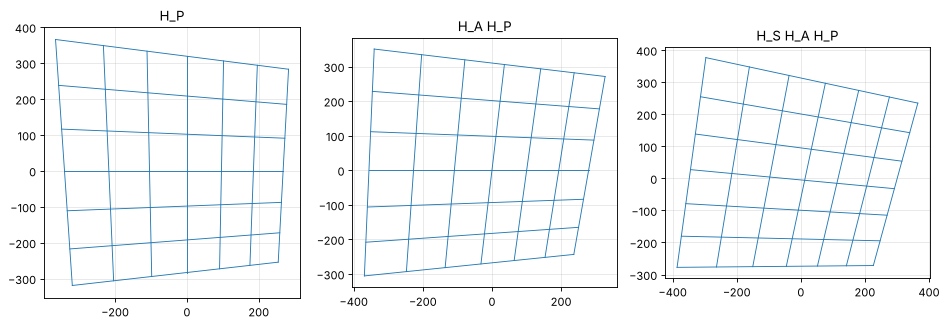

In [14]:
dec = mvg.decompose_projective(H_true)
np.set_printoptions(precision=5, suppress=True)
print("H_S =\n", dec.similarity, "\nH_A =\n", dec.affine, "\nH_P =\n", dec.projective)
print(f"s = {dec.scale:.4f}, angle = {np.degrees(dec.angle):.3f} deg")
assert np.allclose(dec.similarity @ dec.affine @ dec.projective, H_true / H_true[2, 2])

stages = {"H_P": dec.projective, "H_A H_P": dec.affine @ dec.projective,
          "H_S H_A H_P": dec.similarity @ dec.affine @ dec.projective}
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, H) in zip(axes, stages.items()):
    for g in grid_lines(7, -300, 300):
        ax.plot(*mvg.apply_homography(H, g).T, color="C0", lw=0.8)
    ax.set_title(name); ax.set_aspect("equal")
plt.tight_layout()

## 5. Affine rectification from a vanishing line

A floor of square tiles seen in perspective. Two pairs of world-parallel lines give two vanishing points; the
line through them is the image of $\mathbf{l}_\infty$.

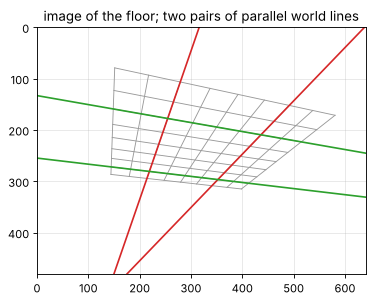

In [15]:
H_floor = np.array([[0.93, 0.19, 320], [0.22, 0.73, 240], [4.3e-4, 1.4e-3, 1.0]])
tiles = [g * 100 for g in grid_lines(9, -2, 2)]
world_lines = {"a": [1, 0, 100.0], "b": [1, 0, -100.0], "c": [0, 1, 100.0], "d": [0, 1, -150.0]}
img_lines = {k: mvg.transform_line(H_floor, np.array(v)) for k, v in world_lines.items()}

fig, ax = plt.subplots(figsize=(6, 4))
for g in tiles:
    ax.plot(*mvg.apply_homography(H_floor, g).T, color="0.6", lw=0.8)
ax.set_xlim(0, 640); ax.set_ylim(480, 0); ax.set_aspect("equal")
for k, li in img_lines.items():
    draw_line(ax, li, color="C1" if k in "ab" else "C2")
ax.set_title("image of the floor; two pairs of parallel world lines");

### ✏️ Exercise 1.4 — the vanishing line

Compute the two vanishing points and the vanishing line from `img_lines` (use only cross products). The check
compares your line with the true image of $\mathbf{l}_\infty$.

In [16]:
v1 = np.cross(img_lines["a"], img_lines["b"])
v2 = np.cross(img_lines["c"], img_lines["d"])
vanishing_line = np.cross(v1, v2)

In [17]:
truth = mvg.transform_line(H_floor, [0, 0, 1.0])
assert np.allclose(mvg.normalize_projective(vanishing_line), mvg.normalize_projective(truth), atol=1e-8)
print("Exercise 1.4 passed; vanishing points:", v1[:2] / v1[2], v2[:2] / v2[2])

Exercise 1.4 passed; vanishing points: [135.71429 521.42857] [2162.7907   511.62791]


Applying $H_{\text{aff}}$ (eq. 1.15) makes the tile edges parallel again. Right angles are not restored — that
needs a metric rectification (HZ §2.7.2), i.e. two more constraints.

H_aff * H_floor is affine


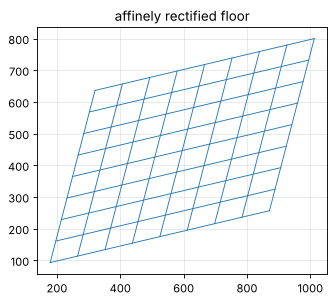

In [18]:
H_aff = mvg.affine_rectification(vanishing_line / vanishing_line[2])
G = H_aff @ H_floor
print("H_aff * H_floor is", mvg.classify_transform(G, 1e-8).name.lower())
fig, ax = plt.subplots(figsize=(5, 4))
for g in tiles:
    ax.plot(*mvg.apply_homography(G, g).T, color="C0", lw=0.8)
ax.set_aspect("equal"); ax.set_title("affinely rectified floor");

## 🔨 Break it

**Nearly parallel lines.** As two lines become parallel their intersection runs off to infinity. In homogeneous
form nothing breaks; dividing by $x_3$ does.

In [19]:
for eps in [1e-1, 1e-4, 1e-8, 0.0]:
    p = mvg.intersect_lines([1, eps, -1.0], [1, 0, 1.0])
    with np.errstate(divide="ignore", invalid="ignore"):
        print(f"eps = {eps:7.0e}  homogeneous = {mvg.normalize_projective(p)}  "
              f"inhomogeneous = {p[:2] / p[2]}")

eps =   1e-01  homogeneous = [-0.04988  0.99751  0.04988]  inhomogeneous = [-1. 20.]
eps =   1e-04  homogeneous = [-0.00005  1.       0.00005]  inhomogeneous = [   -1. 20000.]
eps =   1e-08  homogeneous = [-0.  1.  0.]  inhomogeneous = [-1.e+00  2.e+08]
eps =   0e+00  homogeneous = [-0.  1. -0.]  inhomogeneous = [ nan -inf]


**More perspective.** The affine model fits only while the bottom row of $H$ is small. Increase it and watch the
best affine fit degrade.

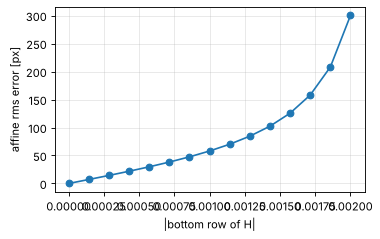

In [20]:
strength = np.linspace(0, 2e-3, 15)
err = []
for s in strength:
    H = H_true.copy(); H[2, :2] = [s, -0.5 * s]
    xp_s = mvg.apply_homography(H, x)
    err.append(mvg.rms_transfer_error(mvg.fit_transform(mvg.TransformClass.AFFINE, x, xp_s), x, xp_s))
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(strength, err, "o-"); ax.set_xlabel("|bottom row of H|"); ax.set_ylabel("affine rms error [px]");

**The wrong rule for lines.** Mapping a line with $H$ instead of $H^{-\top}$ gives a line that misses the mapped
points.

In [21]:
p, q = np.array([10, 20, 1.0]), np.array([200, -50, 1.0])
l = np.cross(p, q)
for name, lp in [("H^-T l", mvg.transform_line(H_true, l)), ("H l (wrong)", H_true @ l)]:
    lp = mvg.normalize_line(lp)
    pp, qq = H_true @ p, H_true @ q
    print(f"{name:<12} distance of mapped points to mapped line: {abs(lp @ (pp / pp[2])):.3e}, "
          f"{abs(lp @ (qq / qq[2])):.3e} px")

H^-T l       distance of mapped points to mapped line: 0.000e+00, 3.553e-15 px
H l (wrong)  distance of mapped points to mapped line: 1.833e+01, 2.041e+02 px


## What to remember

* Homogeneous coordinates make projection, incidence and intersection linear: $\mathbf{l}^\top\mathbf{x} = 0$,
  $\mathbf{x} \times \mathbf{y}$, $\mathbf{l} \times \mathbf{m}$.
* Compare homogeneous vectors up to scale, and keep points at infinity homogeneous.
* Points map with $H$, lines with $H^{-\top}$.
* Each level of the hierarchy keeps fewer invariants; affine maps fix $\mathbf{l}_\infty$, which is why its image
  (the vanishing line) is all that is needed to remove the projective part.
* Fit the simplest model that brings the residual down to the noise level.